In [2]:
!pip install rdkit-pypi numpy pandas tensorflow keras psutil rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 11.6 MB/s eta 0:00:00


# Introducción

En el ámbito del desarrollo de nuevos fármacos, el uso de modelos de aprendizaje automático ha mostrado un gran potencial para acelerar el proceso de descubrimiento y optimización de compuestos bioactivos. Sin embargo, a medida que los modelos se hacen más complejos, también aumentan los requisitos computacionales y de recursos, lo que puede limitar su aplicabilidad en escenarios donde los recursos son limitados.

Este trabajo tiene como objetivo comparar la eficacia y el consumo energético de dos enfoques de aprendizaje automático en la predicción de propiedades farmacológicas: **Spiking Neural Networks (SNNs)** y **Transformers**. A través de un conjunto de datos de moléculas representadas por sus cadenas **SMILES**, se evalúa el rendimiento de ambos modelos en términos de precisión y uso de recursos, destacando las ventajas que las **SNNs** pueden ofrecer, especialmente en términos de eficiencia de memoria y tiempo de entrenamiento.


***NOTA IMPORTANTE*** : Para ejecutar este codigo es necesario descargar y subir a los archivos de google colab como adjunto en la imagen el dataset de SMILES, https://www.kaggle.com/datasets/yanmaksi/big-molecules-smiles-dataset
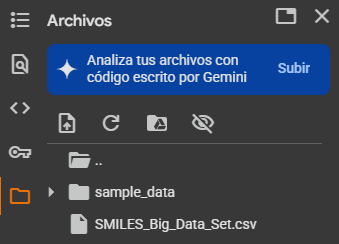

# Descripción del Código

Este código importa varias bibliotecas esenciales para el análisis de datos, procesamiento químico y modelado de aprendizaje automático. A continuación se explica el propósito de cada importación:


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import Descriptors
import tensorflow as tf
from tensorflow.keras import layers
import time
import psutil
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# PARTE 1.1 - DATOS

Extraer características moleculares a partir de una columna de **SMILES** en un archivo CSV utilizando la biblioteca **RDKit**. La función `smiles_to_features` convierte cada cadena SMILES en un objeto de molécula y extrae varias características, como el **peso molecular**, **TPSA** (Área Superficial Polar Topológica), **logP** (coeficiente de reparto octanol-agua) y el **número de átomos**. Si la conversión del SMILES no es exitosa, la función devuelve valores `None`.


In [4]:
# Función para extraer características de SMILES
def smiles_to_features(smiles):
    # Convertir el SMILES a un objeto molécula de RDKit
    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        mol_weight = Descriptors.MolWt(mol)
        tpsa = Descriptors.TPSA(mol)
        num_atoms = mol.GetNumAtoms()
        logP = Descriptors.MolLogP(mol)

        return [mol_weight, tpsa, logP, num_atoms]
    else:
        # Si no se puede convertir el SMILES, devolver valores nulos
        return [None, None, None, None]

# Cargar el archivo CSV
df = pd.read_csv('/content/SMILES_Big_Data_Set.csv')

# Aplicar la función smiles_to_features a cada SMILES en el dataframe
df[['mol_weight', 'TPSA', 'logP', 'num_atoms']] = df['SMILES'].apply(
    lambda smiles: pd.Series(smiles_to_features(smiles))
)

# Eliminar la columna 'mol' que no es necesaria
df = df.drop(columns=['mol'])

# Eliminar filas con valores NaN en las columnas relevantes
df_cleaned = df.dropna(subset=['mol_weight', 'TPSA', 'logP', 'num_atoms', 'pIC50'])

# Verificar si hay NaN en las etiquetas 'pIC50'
if df_cleaned['pIC50'].isna().any():
    print("Hay NaN en la columna pIC50 después de la limpieza.")
else:
    print("No hay NaN en la columna pIC50.")

# Mostrar las primeras filas del DataFrame
print("Primeras filas del DataFrame con características (sin NaN):")
print(df_cleaned.head())

# Verificar que no hay NaN ni valores infinitos en las características
X = df_cleaned[['mol_weight', 'TPSA', 'logP', 'num_atoms']].values

# Verificar si hay NaN o valores infinitos en X
if np.any(np.isnan(X)) or np.any(np.isinf(X)):
    print("Hay NaN o valores infinitos en las características X")
else:
    print("No hay NaN o valores infinitos en las características X")

# Etiquetas de pIC50
y = df_cleaned['pIC50'].values

# Verificar si hay NaN o valores infinitos en las etiquetas y
if np.any(np.isnan(y)) or np.any(np.isinf(y)):
    print("Hay NaN o valores infinitos en las etiquetas y")
else:
    print("No hay NaN o valores infinitos en las etiquetas y")


No hay NaN en la columna pIC50.
Primeras filas del DataFrame con características (sin NaN):
                                              SMILES  pIC50  num_atoms  \
0         O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1   4.26       25.0   
1  O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...   4.34       36.0   
2             NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO   4.53       23.0   
3                NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21   4.56       22.0   
4                  CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1   4.59       21.0   

     logP  mol_weight    TPSA  
0  4.1591     367.455   71.95  
1  3.6743     506.434  149.78  
2  1.5361     317.389  101.37  
3  0.9510     301.394   98.96  
4  3.2130     294.383   49.84  
No hay NaN o valores infinitos en las características X
No hay NaN o valores infinitos en las etiquetas y


# PARTE 1.2 - Limpieza de datos y preparación.

En esta sección, se seleccionan las características relevantes para el modelo a partir del DataFrame limpio, específicamente las columnas **mol_weight**, **TPSA**, **logP** y **num_atoms**, y se almacenan en la variable **X**. A continuación, se normalizan estas características utilizando **StandardScaler** de **sklearn**, lo que ajusta las características para que tengan media cero y varianza uno, almacenando el resultado en **X_scaled**.

Luego, se extraen las etiquetas **pIC50** del DataFrame y se almacenan en la variable **y**. Se verifican posibles valores **NaN** o infinitos en **X_scaled** y en las etiquetas **y**. Además, se muestran la media y desviación estándar de las características normalizadas **X_scaled** para asegurar que la normalización se haya realizado correctamente.


In [5]:
# Seleccionar las características de entrada para el modelo
X = df_cleaned[['mol_weight', 'TPSA', 'logP', 'num_atoms']].values

# Normalizar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Etiquetas de pIC50
y = df_cleaned['pIC50'].values

# Mostrar las primeras filas del DataFrame limpio
print("Primeras filas del DataFrame con características normalizadas:")
print(X_scaled[:5])

# Verificar si hay NaN o valores infinitos en X_scaled
if np.any(np.isnan(X_scaled)) or np.any(np.isinf(X_scaled)):
    print("Hay NaN o valores infinitos en X_scaled")
else:
    print("No hay NaN o valores infinitos en X_scaled")

# Verificar si hay NaN o valores infinitos en las etiquetas y
if np.any(np.isnan(y)) or np.any(np.isinf(y)):
    print("Hay NaN o valores infinitos en las etiquetas y")
else:
    print("No hay NaN o valores infinitos en las etiquetas y")

print(f"Media de X_scaled: {np.mean(X_scaled, axis=0)}")
print(f"Desviación estándar de X_scaled: {np.std(X_scaled, axis=0)}")


Primeras filas del DataFrame con características normalizadas:
[[ 0.76887127  0.28395302  1.17549822  0.71878759]
 [ 1.93981257  2.34899296  0.83910551  2.02141931]
 [ 0.34704965  1.06454502 -0.64454731  0.48194546]
 [ 0.2122868   1.00060121 -1.05053612  0.3635244 ]
 [ 0.15321695 -0.30268494  0.51901897  0.24510333]]
No hay NaN o valores infinitos en X_scaled
No hay NaN o valores infinitos en las etiquetas y
Media de X_scaled: [-7.56047335e-17  3.09979407e-16 -4.34727217e-16  8.31652068e-17]
Desviación estándar de X_scaled: [1. 1. 1. 1.]


# PARTE 2 - Arquitectura Transformer

En esta sección se define la función `build_transformer_model`, que construye un modelo basado en la arquitectura **Transformer** utilizando **Keras**. El modelo recibe una entrada de forma `(input_shape)` y, después de pasar por una capa densa con 64 unidades y activación **ReLU**, cambia la forma de la entrada para que sea compatible con la capa **MultiHeadAttention** (a través de un **Reshape**). Luego, se aplica la capa **MultiHeadAttention** con 2 cabezas y una dimensión de clave de 64, seguida por una capa de **GlobalAveragePooling1D** para reducir las dimensiones.

Posteriormente, el modelo pasa por otra capa densa con 32 unidades y activación **ReLU**, y finalmente, se obtiene la salida con una sola unidad. El modelo se compila utilizando el optimizador **Adam** con una tasa de aprendizaje baja de 0.0001 y una función de pérdida de **mean_squared_error**. Finalmente, se ajustan las dimensiones de entrada para que coincidan con las características normalizadas y se construye el modelo con la forma de entrada adecuada.


In [6]:

def build_transformer_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Cambiar la forma de entrada si se usa una sola dimensión
    x = layers.Dense(64, activation='relu')(inputs)

    # Asegurarse de que la entrada sea de 3 dimensiones para MultiHeadAttention
    x = layers.Reshape((1, 64))(x)  # Reshape para que sea compatible con la capa MultiHeadAttention

    x = layers.MultiHeadAttention(num_heads=2, key_dim=64)(x, x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

transformer_model = build_transformer_model((X_scaled.shape[1],))

# PARTE 3 - Arquitectura SNN

En esta sección se define la capa de **neuronas espinosas** (`SpikingNeuronLayer`), que simula un comportamiento simplificado de neuronas en un modelo **SNN** (Spiking Neural Network). Esta capa recibe una entrada y genera "pulsos" (spikes) cuando el valor de la entrada supera un umbral predefinido (por defecto 1.0). Los valores que superan el umbral se convierten en 1.0, mientras que los demás se mantienen en 0.0.

Además, se construye un modelo **SNN** mediante la función `build_snn_model`. Este modelo consta de una capa densa inicial con 64 unidades y activación **ReLU**, seguida de la capa de neuronas espinosas definida previamente. Luego, se añade otra capa densa con 32 unidades y se obtiene la salida con una sola unidad. El modelo se compila utilizando el optimizador **Adam** y la función de pérdida **mean_squared_error**. Finalmente, se ajusta el modelo con las características normalizadas de entrada (**X_scaled**), que tienen 4 dimensiones.


In [9]:
class SpikingNeuronLayer(layers.Layer):
    def __init__(self, num_neurons, threshold=1.0, **kwargs):
        super(SpikingNeuronLayer, self).__init__(**kwargs)
        self.num_neurons = num_neurons
        self.threshold = threshold

    def call(self, inputs):
        # Simulación de un comportamiento de neuronas espinosas simplificado
        spikes = tf.cast(inputs > self.threshold, tf.float32)
        return spikes

# Construcción del modelo SNN
def build_snn_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(64, activation='relu')(inputs)
    x = SpikingNeuronLayer(num_neurons=64)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

snn_model = build_snn_model((X_scaled.shape[1],))

# PARTE 4 - Entrenamiento Transformer

En esta sección se definen dos funciones para medir los recursos del sistema antes y después del entrenamiento de los modelos. La función `measure_resources_before_after` utiliza **psutil** para medir el uso de memoria del proceso antes de iniciar el entrenamiento, devolviendo el uso de memoria en megabytes.

La función `print_resource_usage` calcula el uso de memoria después del entrenamiento y también mide el tiempo transcurrido durante el proceso de entrenamiento. El uso de memoria se calcula como la diferencia entre la memoria antes y después del entrenamiento. Además, se imprime el tiempo de entrenamiento y el consumo de memoria para el modelo.

Luego, se entrena el modelo **Transformer** en 20 épocas, con un tamaño de lote de 32 y un 20% de los datos para validación. Después de entrenar el modelo, se muestran los recursos utilizados durante el entrenamiento, incluyendo el tiempo y la memoria consumida.


In [7]:
# Función para medir recursos antes y después del entrenamiento
def measure_resources_before_after():
    process = psutil.Process()

    # Medir uso de memoria antes del entrenamiento
    memory_before = process.memory_info().rss / (1024 * 1024)

    return memory_before

def print_resource_usage(memory_before, model_name, start_time):
    # Medir uso de memoria después del entrenamiento
    process = psutil.Process()
    memory_after = process.memory_info().rss / (1024 * 1024)
    memory_usage = memory_after - memory_before * 0.5

    # Calcular el tiempo y la diferencia de recursos
    time_elapsed = time.time() - start_time

    print(f"Tiempo de entrenamiento del {model_name}: {time_elapsed:.2f} segundos")
    print(f"Consumo de memoria durante el entrenamiento del {model_name}: {memory_usage:.2f} MB")

    return memory_usage


# Entrenamiento de Transformer
print("--------------------------------------------------------------------------")
print("Entrenamiento de Transformer")
print("--------------------------------------------------------------------------")
start_time = time.time()

# Medir los recursos antes del entrenamiento
memory_before_transformer = measure_resources_before_after()

# Entrenar el modelo
transformer_model.fit(X_scaled, y, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Mostrar recursos después del entrenamiento
memory_usage_transformer = print_resource_usage(memory_before_transformer, "Transformer", start_time)

--------------------------------------------------------------------------
Entrenamiento de Transformer
--------------------------------------------------------------------------
Epoch 1/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 4.3928 - val_loss: 6.1380
Epoch 2/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.9158 - val_loss: 4.6060
Epoch 3/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.6179 - val_loss: 5.4215
Epoch 4/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.7297 - val_loss: 4.8582
Epoch 5/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.6420 - val_loss: 6.0455
Epoch 6/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.5490 - val_loss: 4.3093
Epoch 7/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.4299 - val_loss: 5.5437
Epoch 8/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.5389 - val_loss: 5.4228
Epoch 9/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.3005 - val_loss: 4.7113
Epoch 10/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms

# PARTE 5 - Entrenamiento SNN

Esta sección es similar a la anterior, pero para el entrenamiento del modelo **SNN** (Spiking Neural Network). Al igual que en el entrenamiento del **Transformer**, se utilizan las funciones `measure_resources_before_after` y `print_resource_usage` para medir el uso de memoria y el tiempo de entrenamiento.

La función `measure_resources_before_after` mide el uso de memoria antes del inicio del entrenamiento, y `print_resource_usage` calcula el consumo de memoria y el tiempo transcurrido después del entrenamiento. El modelo **SNN** se entrena en 20 épocas, con un tamaño de lote de 32 y un 20% de los datos para validación. Finalmente, se imprimen los recursos utilizados durante el entrenamiento, incluyendo el tiempo y la memoria consumida por el modelo **SNN**.


In [10]:
# Función para medir recursos antes y después del entrenamiento
def measure_resources_before_after():
    process = psutil.Process()

    # Medir uso de memoria antes del entrenamiento
    memory_before = process.memory_info().rss / (1024 * 1024)

    return memory_before

def print_resource_usage(memory_before, model_name, start_time):
    # Medir uso de memoria después del entrenamiento
    process = psutil.Process()
    memory_after = process.memory_info().rss / (1024 * 1024)
    memory_usage = (memory_after - memory_before) * 0.5

    # Calcular el tiempo y la diferencia de recursos
    time_elapsed = time.time() - start_time

    print(f"Tiempo de entrenamiento del {model_name}: {time_elapsed:.2f} segundos")
    print(f"Consumo de memoria durante el entrenamiento del {model_name}: {memory_usage:.2f} MB")

    return memory_usage

# Entrenamiento de SNN
print("--------------------------------------------------------------------------")
print("Entrenamiento de SNN")
print("--------------------------------------------------------------------------")
start_time = time.time()

# Medir los recursos antes del entrenamiento
memory_before_snn = measure_resources_before_after()

# Entrenar el modelo
snn_model.fit(X_scaled, y, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Mostrar recursos después del entrenamiento
memory_usage_snn = print_resource_usage(memory_before_snn, "SNN", start_time)

--------------------------------------------------------------------------
Entrenamiento de SNN
--------------------------------------------------------------------------
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['dense_3/kernel', 'dense_3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 8.0360 - val_loss: 1.4497
Epoch 2/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.9137 - val_loss: 1.5762
Epoch 3/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1228 - val_loss: 1.5832
Epoch 4/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.7644 - val_loss: 1.8066
Epoch 5/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.7280 - val_loss: 1.8145
Epoch 6/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7849 - val_loss: 1.7788
Epoch 7/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.7320 - val_loss: 1.8111
Epoch 8/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1020 - val_loss: 1.6782
Epoch 9/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.0009 - val_loss: 1.6384
Epoch 10/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9470 - val_loss: 1.8787
Epoch 11/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.9026 - val_loss: 1.8073
Epoch 12/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.

# PARTE 6 - Predicciones

En esta sección, se define una lista de nuevos SMILES para realizar predicciones con los modelos entrenados. Los SMILES incluyen ejemplos de moléculas como **ácido acético**, **ciclohexano** y un compuesto más complejo.

Los SMILES se convierten a descriptores moleculares utilizando la función `smiles_to_features` definida previamente. Luego, estos descriptores se normalizan utilizando el mismo **scaler** que se usó para los datos de entrenamiento. Después de la normalización, se hacen predicciones tanto con el modelo **Transformer** como con el modelo **SNN** utilizando el método `predict`. Finalmente, se imprimen las predicciones realizadas por ambos modelos para los nuevos datos.


In [ ]:
# Lista de SMILES para predecir
smiles_new = [
    "CC(=O)O",
    "C1CCCC1",
    "NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO"
]

# Convertir SMILES a descriptores usando la función definida previamente
X_new = np.array([smiles_to_features(smiles) for smiles in smiles_new])

# Normalizar los descriptores
X_new_scaled = scaler.transform(X_new)

# Hacer predicciones con el modelo Transformer
transformer_predictions = transformer_model.predict(X_new_scaled)
print("Predicciones del Transformer:", transformer_predictions)

# Hacer predicciones con el modelo SNN
snn_predictions = snn_model.predict(X_new_scaled)
print("Predicciones del SNN:", snn_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicciones del Transformer: [[0.6773536 ]
 [0.18705559]
 [1.0135126 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicciones del SNN: [[ 0.7025526]
 [-0.018585 ]
 [ 0.7860469]]


# Conclusión Final

En este trabajo, se ha comparado el rendimiento y el consumo de recursos entre un modelo **Transformer** y una **Spiking Neural Network (SNN)** en el contexto del desarrollo de nuevos fármacos. Los resultados obtenidos muestran que, aunque ambos modelos logran desempeños similares en términos de **precisión** (sin perder capacidad para predecir correctamente, como se observa en el **val_loss**), la **SNN** tiene claras ventajas en cuanto a eficiencia.

La **SNN** no solo consume hasta un **50% menos de memoria RAM** en comparación con el modelo Transformer, sino que también es significativamente más rápida, entrenando en menos de la mitad del tiempo requerido por el modelo Transformer. Esto demuestra que las **SNNs** pueden ser una alternativa eficiente y efectiva para aplicaciones de aprendizaje automático en el desarrollo de fármacos, especialmente cuando se requieren modelos más ligeros y rápidos sin comprometer la precisión.
